Usaremos o dataset **Ames Housing** para construir um modelo de regressão.

**Objetivo:** Prever o preço final de venda (`SalePrice`) de cada casa, com base em suas características.

## 1. Setup Inicial

Primeiro, vamos importar todas as bibliotecas que precisaremos ao longo do exercício.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

sns.set(style="whitegrid")

## 2. Obtenção dos Dados

Vamos carregar o dataset Ames Housing diretamente do OpenML.

In [2]:
housing = fetch_openml(name="house_prices", as_frame=True)
df = housing.frame
print("Dados carregados com sucesso!")

Dados carregados com sucesso!


## 3. Exploração dos Dados

### **Exercício 1: Explorar o conteúdo do DataFrame**

Use os métodos do Pandas para visualizar as primeiras linhas, obter um resumo das colunas (tipos de dados e valores nulos) e gerar estatísticas descritivas.

In [3]:
print("As 5 primeiras linhas (head):")
df.head

print("\nResumo dos dados (info):")
df.info()

print("\nEstatísticas Descritivas (describe):")
df.describe()

# Categorias de cada atributo categórico
print("\nCategorias de cada atributo categórico:")
for col in df.select_dtypes(include=['object', 'category']):
    print(f"{col}: {df[col].unique()}")

As 5 primeiras linhas (head):

Resumo dos dados (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 

### **Exercício 2: Gerar os histogramas**

Visualize a distribuição dos atributos numéricos.
Use o parâmetro `figsize=(20,15)` do método `hist` para melhorar a visualização. É possível identificar fortes assimetrias e valores truncados?


Histogramas dos atributos numéricos:


array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

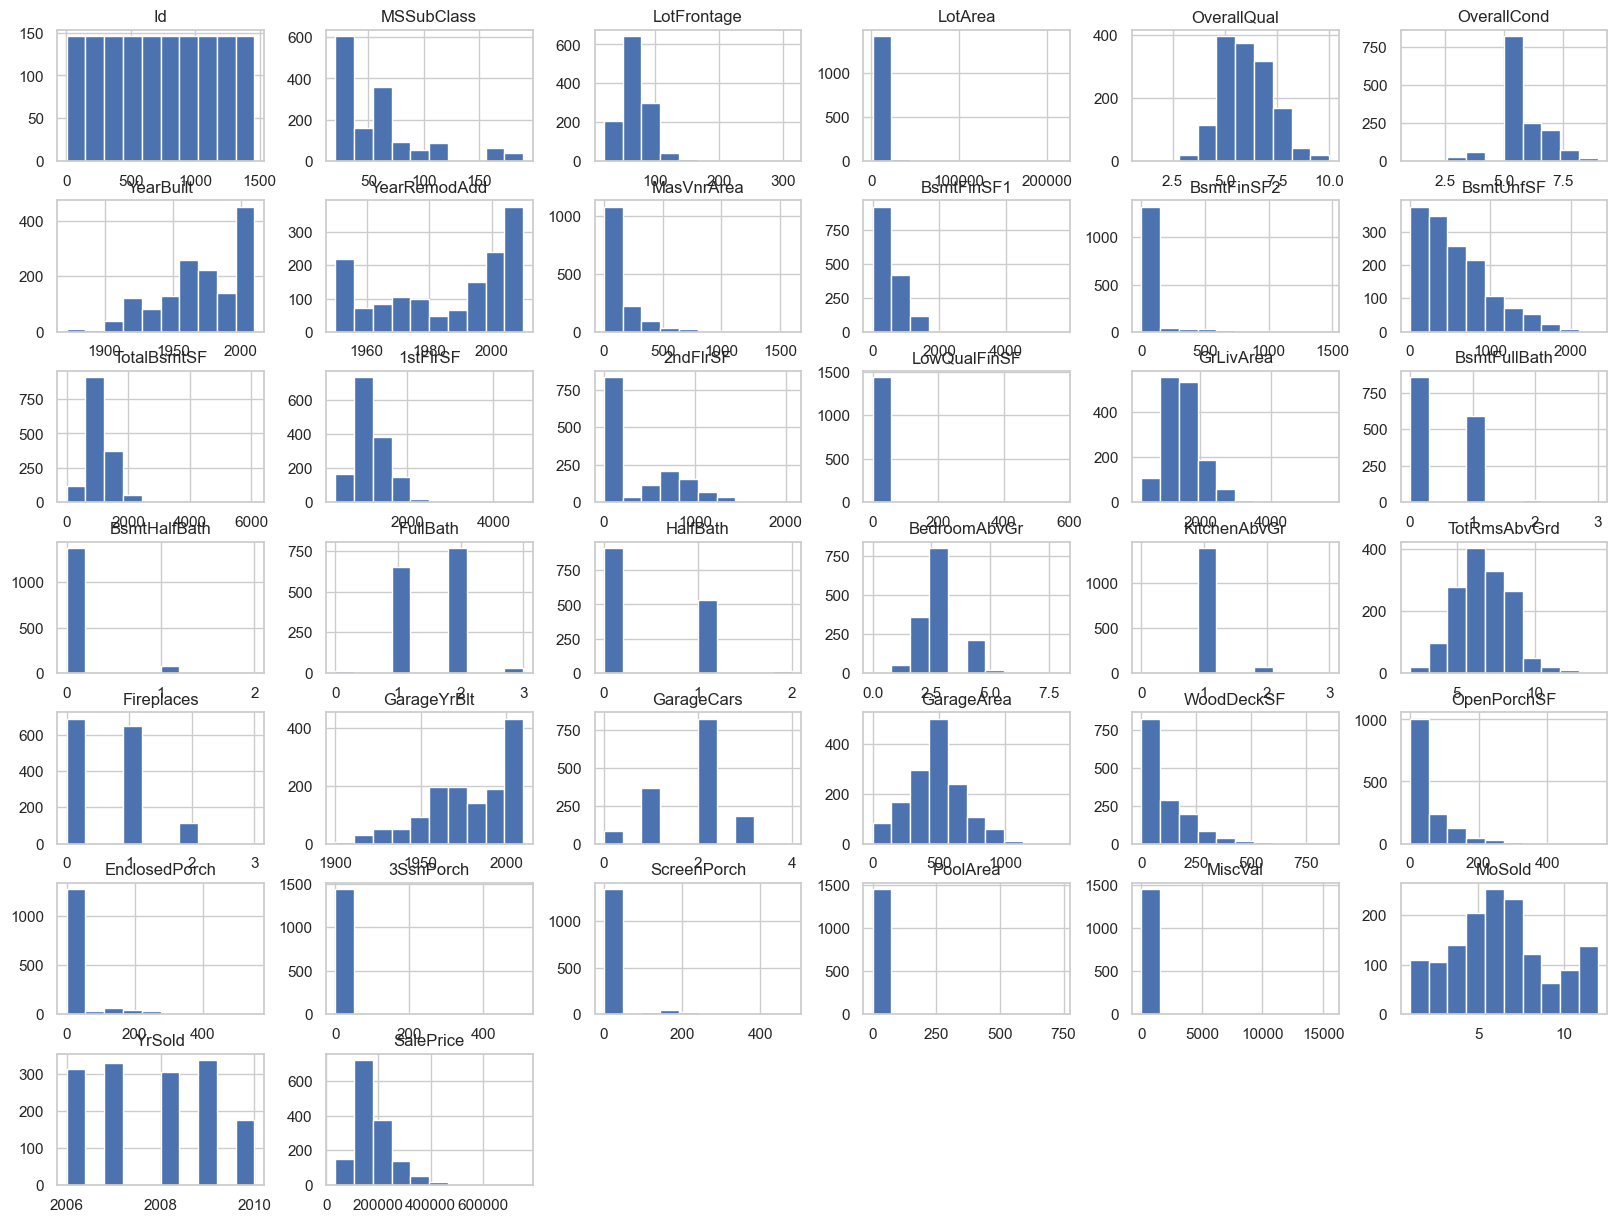

In [4]:
print("\nHistogramas dos atributos numéricos:")
df.hist(figsize=(20,15))


### **Exercício 3: Listar os atributos mais correlacionados com o target**

Calcule a correlação de Pearson de todos os atributos em relação ao atributo alvo (`SalePrice`) e exiba os atributos em ordem decrescente de correlação.
Lembre de usar o parâmetro `numeric_only=True` no método `corr`, para evitar o erro provocado ao tentar calcular correlação envolvendo atributos categóricos.

In [5]:
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)


SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

Faça o scatter plot do atributo de maior correlação (em módulo) e do atributo `SalePrice`.
Faça também um scatter plot para o segundo atributo de maior correlação (em módulo) e o atributo `SalePrice`. É possível observar uma relação aproximadamente linear?

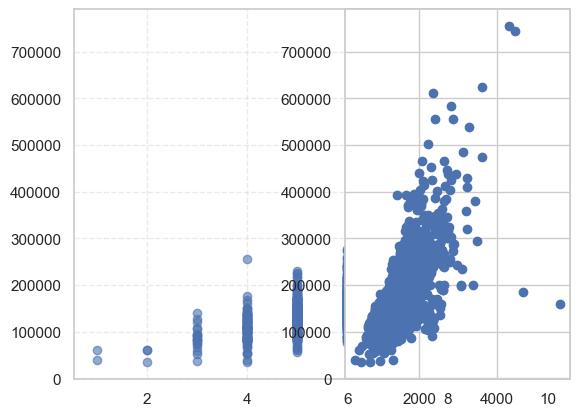

In [14]:
eixo_Y = df['SalePrice']

eixo_X_1 = df['OverallQual']
eixo_X_2 = df['GrLivArea']


plt.scatter(eixo_X_1,eixo_Y, alpha=0.6)
plt.grid(True, linestyle='--', alpha=0.4)

plt.subplot(1, 2, 2)
plt.scatter(eixo_X_2, eixo_Y)




## 4. Preparação dos Dados

### **Exercício 4: Separar os conjuntos de treino e teste**

Para melhorar a eficiência dos experimentos, vamos usar apenas os atributos `OverallQual`, `GrLivArea`, `Neighborhood` e `GarageCars` (código fornecido abaixo).

Para garantir que a distribuição de preços seja semelhante nos conjuntos de treino e teste, vamos criar uma categoria de preços para usar na amostragem estratificada (código fornecido abaixo).

Em seguida, faça a divisão das instâncias em `train_set` e `test_set` usando a função `train_test_split`, deixando 20% das instâncias no conjunto de teste, e usando `random_state=42`.

Vamos chamar as features do conjunto de treino de `housing_features`, e seus rótulos de `housing_labels` (código fornecido abaixo).

In [22]:
#df = df[["OverallQual", "GrLivArea", "Neighborhood", "GarageCars", "SalePrice"]].copy()
df = df[["OverallQual", "GrLivArea", "GarageCars", "SalePrice"]].copy()


df["price_cat"] = pd.cut(df["SalePrice"],
                            bins=[0., 100000, 150000, 200000, 300000, np.inf],
                            labels=[1, 2, 3, 4, 5])


train_set, test_set  = train_test_split(df, test_size=0.2, random_state=42)

for set_ in (train_set, test_set):
    set_.drop("price_cat", axis=1, inplace=True)

print(f"Tamanho do conjunto de treino: {len(train_set)}")
print(f"Tamanho do conjunto de teste: {len(test_set)}")

housing_features = train_set.drop("SalePrice", axis=1)
housing_labels = train_set["SalePrice"].copy()

Tamanho do conjunto de treino: 1168
Tamanho do conjunto de teste: 292


### **Exercício 5: Criar um Pipeline de Pré-processamento Completo**

Crie um `ColumnTransformer` (chamado `preprocessor`) que:
- Preencha os valores faltantes dos atributos numéricos com a mediana e os padronize.
- Preencha os valores faltantes dos atributos categóricos com o valor mais frequente (`SimpleImputer(strategy='most_frequent')`) e aplique One-Hot encoding.

Em seguida, aplicamos esta transformação nas features (`housing_features`), e armazenamos o resultado em `housing_prepared` (código fornecido abaixo).

In [8]:
preprocessor = SimpleImputer(strategy='most_frequent')

housing_prepared = preprocessor.fit_transform(housing_features)

## 5. Seleção e Treinamento de Modelos

### **Exercício 6: Treinar e avaliar modelos de base**

Treine os modelos `LinearRegression`, `DecisionTreeRegressor` e `RandomForestRegressor` com parâmetros default e `random_state=42` e imprima o RMSE de cada um no conjunto de treino.

In [ ]:
LR_Model = LinearRegression()
LR_Model.fit(housing_prepared, housing_labels)
y_predict = LR_Model.predict(housing_prepared)
print(mean_squared_error(housing_labels,y_predict))

# DTR_model = DecisionTreeRegressor(random_state=42)
# DTR_model.fit(housing_prepared, housing_labels)

# RFR_model = RandomForestRegressor(random_state=42)
# RFR_model.fit(housing_prepared, housing_labels)




1599499383.1692665


RMSE no conjunto de treino:
LinearRegression: $35,254.91
DecisionTreeRegressor: $2,465.67
RandomForestRegressor: $13,196.16

### **Exercício 7: Validação cruzada para o RandomForestRegressor**

Avalie o `RandomForestRegressor` (com parâmetros default, e `random_state=42`) usando validação cruzada com 10 folds para ter uma estimativa mais robusta de seu desempenho. Qual a média e desvio padrão do RMSE?

In [10]:
# SEU CÓDIGO AQUI


## 6. Ajuste Fino e Avaliação Final

### **Exercício 8: Otimização com GridSearchCV**

Use `GridSearchCV` para encontrar os melhores hiperparâmetros para o `RandomForestRegressor`. Teste os valores 20, 30 e 50 para o parâmetro `n_estimators`. Use 5 folds na validação cruzada.

Qual o melhor RMSE encontrado? Para qual valor do parâmetro `n_estimators`?

In [11]:
# SEU CÓDIGO AQUI


### **Exercício 9: Avaliar o melhor modelo no conjunto de teste**

Finalmente, avalie no conjunto de teste o desempenho do melhor modelo obtido na otimização de hiparparâmetros. Lembre de aplicar o pré-processamento nos atributos do conjunto de teste.

Qual RMSE obtido?

In [12]:
# SEU CÓDIGO AQUI
